# Overview
This notebooks is intended to estimate net worth change for two housing strategies over different time horizons and under different assumptions.

# Notation
## Big Idea
We are tracking net worth over time:

$$
\text{NW}_s(t) = \text{Assets}_s(t) - \text{Liabilities}_s(t)
$$

for $s\in\{ \text{Rent}, \text{Buy}  \}$ with special interest in the quantity:

$$
\Delta(t) = \text{NW}_{buy}(t) - \text{NW}_{rent}(t)
$$

for $t \in \{ 1, 2, 3, 5, 7 \}$ years.

For a subset of the parameter space, we will run Monte Carlo simulations to estimate the distribution of $\Delta(t)$.

# Imports

In [43]:
import numpy as np
import pandas as pd

from housing.params import (
    MarginalDist, StochasticParams, DeterministicParams, DEFAULT_CORRELATION,
)
from housing.simulation import run_monte_carlo
from housing.plotting import (
    delta_summary, plot_delta_violin, plot_prob_buy_wins,
    plot_delta_fan, plot_net_worth_comparison,
)

# Setup

In [44]:
# Key parameters
appreciation_mean = 0.06
home_price = 700_000
down_payment = 100_000

In [45]:
stochastic_params = StochasticParams(
    appreciation=MarginalDist(mean=0.06, std=0.06),
    investment_return=MarginalDist(mean=0.07, std=0.15),
    rent_growth=MarginalDist(mean=0.03, std=0.02),
    correlation=DEFAULT_CORRELATION
)

deterministic_params = DeterministicParams(
    home_price=700_000,
    down_payment=100_000,
    interest_rate=0.065,
    loan_term_years=30,
    property_tax_rate=0.012,
    hoa_monthly=350,
    insurance_monthly=150,
    maintenance_rate=0.01,
    buy_closing_cost_rate=0.03,
    sell_transaction_cost_rate=0.06,
    rent_monthly_initial=2_500,
    initial_savings=150_000,
    monthly_income=180_000 // 12,
    ltcg_rate=0.15,
    stcg_rate=0.24,
    home_sale_exclusion=250_000,
    marginal_tax_rate=0.24,
    standard_deduction=14_600,
    salt_deduction=10_000,
)

horizons = list(range(1, 11))

rng = np.random.default_rng(42)

# Simulation

In [46]:
results = run_monte_carlo(deterministic_params, stochastic_params, n_trials=10_000, rng=rng, horizons=horizons)

## Summary Statistics

In [47]:
summary = delta_summary(results)

In [48]:
summary

,mean,median,std,p10,p25,p75,p90,prob_buy_wins
horizon_years,,,,,,,,
1,"$-63,330","$-62,809","$30,481","$-102,007","$-83,072","$-42,756","$-25,395",1.8%
2,"$-44,186","$-44,558","$56,810","$-116,298","$-83,427","$-7,134","$29,719",21.4%
3,"$-35,586","$-37,482","$74,554","$-129,701","$-86,986","$14,979","$61,184",31.2%
4,"$-28,148","$-28,780","$89,080","$-139,976","$-89,774","$32,951","$85,299",37.7%
5,"$-22,103","$-23,340","$103,924","$-154,636","$-91,240","$46,727","$110,995",41.4%
6,"$-17,260","$-17,182","$121,338","$-172,174","$-96,540","$61,530","$138,334",44.2%
7,"$-13,480","$-13,214","$140,615","$-190,119","$-107,448","$79,072","$164,600",46.5%
8,"$-12,126","$-9,489","$163,086","$-218,198","$-115,976","$93,602","$193,297",47.5%
9,"$-11,492","$-7,513","$188,088","$-244,747","$-130,715","$110,533","$220,580",48.5%


## Distribution by Horizon

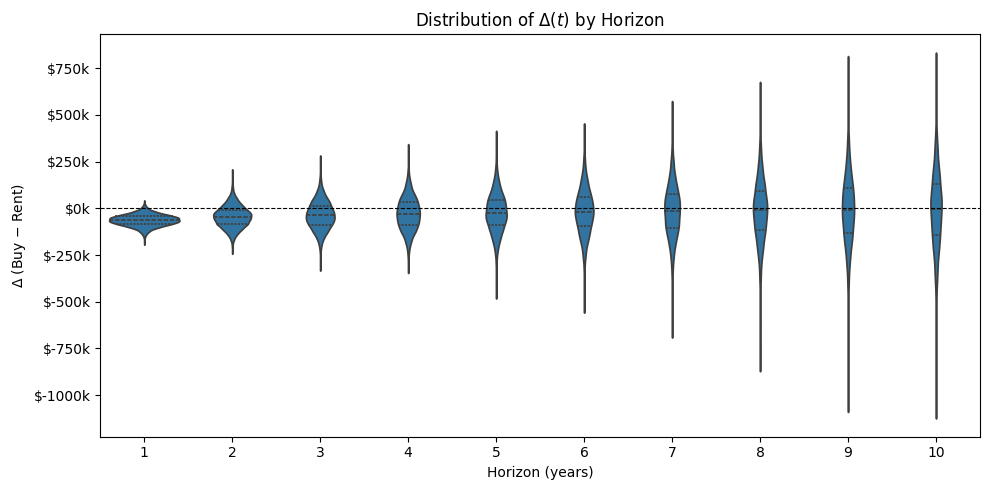

In [49]:
plot_delta_violin(results);

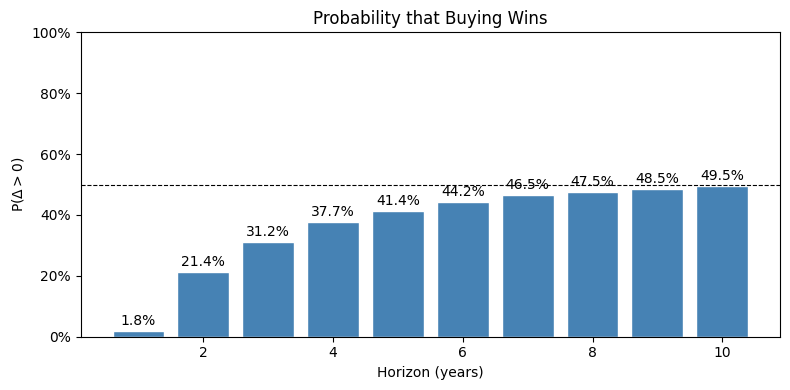

In [50]:
plot_prob_buy_wins(results);

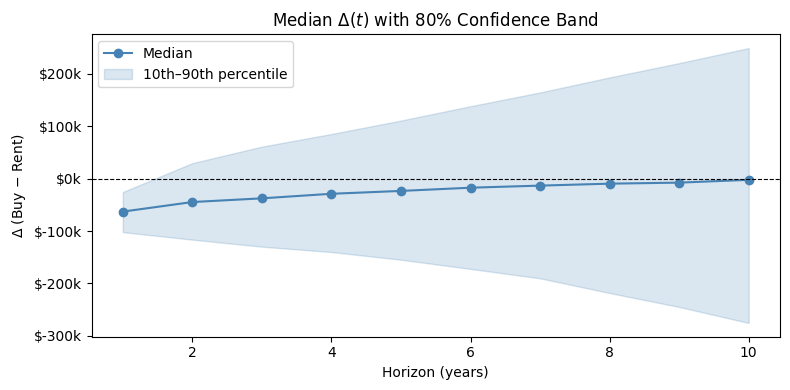

In [51]:
plot_delta_fan(results);

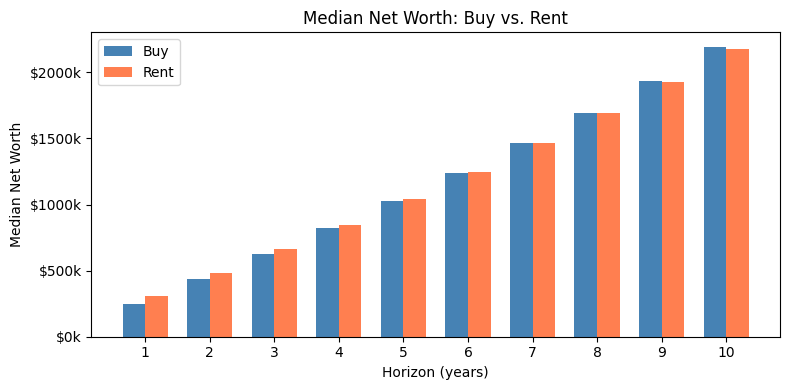

In [52]:
plot_net_worth_comparison(results);

# Summary

This simulation compares **buying** (a $700K home with $100K down at 6.5% interest) vs. **renting** ($2,500/mo initial rent) over 1–10 year horizons using 10,000 Monte Carlo trials.

## Key Findings

**Buying is a losing proposition on average across all horizons tested**, though the gap narrows over time:

| Horizon | Mean Δ (Buy − Rent) | Median Δ | P(Buy Wins) |
|---------|---------------------|----------|-------------|
| 1 yr    | −$63,330            | −$62,809 | 1.8%        |
| 3 yr    | −$35,586            | −$37,482 | 31.2%       |
| 5 yr    | −$22,103            | −$23,340 | 41.4%       |
| 7 yr    | −$13,480            | −$13,214 | 46.5%       |
| 10 yr   | −$11,652            | −$2,206  | 49.5%       |

### Interpretation

1. **Short-term buying is heavily penalized.** Transaction costs (3% buy + 6% sell) create ~$63K drag at year 1 that is almost never overcome. Only 1.8% of simulations favor buying at the 1-year mark.

2. **The gap closes but never flips.** By year 10, the median delta is only −$2,206 and buying wins in 49.5% of simulations — essentially a coin flip — but the *mean* remains −$11,652, indicating a negatively skewed distribution (bad outcomes for buyers are worse than good outcomes are good).

3. **Uncertainty grows substantially with horizon.** Standard deviation rises from ~$30K (year 1) to ~$213K (year 10), reflecting compounding volatility in appreciation and investment returns. The p10–p90 range at year 10 spans roughly $525K.

4. **Under these assumptions, renting and investing the difference is slightly favored** even at a 10-year horizon, primarily due to the high transaction costs of buying/selling and the relatively high mortgage rate (6.5%) compared to expected investment returns (7% mean).

### Sensitivity Drivers
The result is most sensitive to: home appreciation rate (6% mean assumed), mortgage rate (6.5%), and sell-side transaction costs (6%). A lower mortgage rate, higher appreciation, or longer hold period would shift results toward buying.